In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import datetime as dt
from datetime import datetime
from pandas_datareader import data as pdr
import missingno as msno
#pd.set_option('display.max_rows', None)
#pd.set_option('display.float_format', lambda x: '%.3f' % x)
#pd.reset_option("all")
#pd.options.display.float_format = '{:,}'.format
sns.set_theme(rc={'figure.figsize':(11.7,6.5)})


# Collection

In [61]:
series = {
    "CPIAUCSL": "cpi",
    "PAYEMS": "nonfarm_unemployment",
    "MORTGAGE30US": "30yr_mortgage",
    "MORTGAGE15US": "15yr_mortgage",
    "UNRATENSA": "unemployment_rate",
    "UNRATE": "unemployment_rate",
    "FEDFUNDS": "fed_funds",
    "DRCLACBS":"delinquencies",
    "GS10": "ten_year",
    "GS2": "two_year",
    "GDPC1": "real_gdp",
    "OPHNFB": "labor_productivity",
    "ULCNFB": "unit_labor_cost",
    "ECIWAG": "wage_index",
    "INDPRO": "industrial_production",
    "RSAFS": "retail_sales",
    "RPI": "real_pi",
   
}

dfs = []
for code, name in series.items():
    s = pdr.get_data_fred(code, start="1990-01-01")
    s = s.rename(columns={code: name})
    dfs.append(s)

df = pd.concat(dfs, axis=1).resample("D").mean()

df = df.sort_index(ascending = True)

#inf['cpi'] = round(inf.cpi,2)

df['inflation_rt'] = (
    df['cpi'] /
    df['cpi'].shift(365) - 1
) * 100


#df["wage_growth_yoy"] = df["wage_index"].pct_change(4) * 100
#df["real_wage_growth"] = df["wage_growth_yoy"] - df["inflation_yoy"]

df = df.dropna(how='all')

In [63]:
print(df.shape)
df.sort_index(ascending = False).head()

(2283, 18)


,cpi,nonfarm_unemployment,30yr_mortgage,15yr_mortgage,unemployment_rate,unemployment_rate,fed_funds,delinquencies,ten_year,two_year,real_gdp,labor_productivity,unit_labor_cost,wage_index,industrial_production,retail_sales,real_pi,inflation_rt
DATE,,,,,,,,,,,,,,,,,,
2026-06-18,NaN,NaN,6.47,5.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-11,NaN,NaN,6.52,5.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-04,NaN,NaN,6.48,5.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-28,NaN,NaN,6.53,5.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-21,NaN,NaN,6.51,5.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df.dtypes

cpi                      float64
nonfarm_unemployment     float64
30yr_mortgage            float64
15yr_mortgage            float64
unemployment_rate        float64
unemployment_rate        float64
fed_funds                float64
delinquencies            float64
ten_year                 float64
two_year                 float64
real_gdp                 float64
labor_productivity       float64
unit_labor_cost          float64
wage_index               float64
industrial_production    float64
retail_sales             float64
real_pi                  float64
dtype: object

In [46]:
print(df.shape)
print(df.index.drop_duplicates().shape)

(13318, 17)
(13318,)


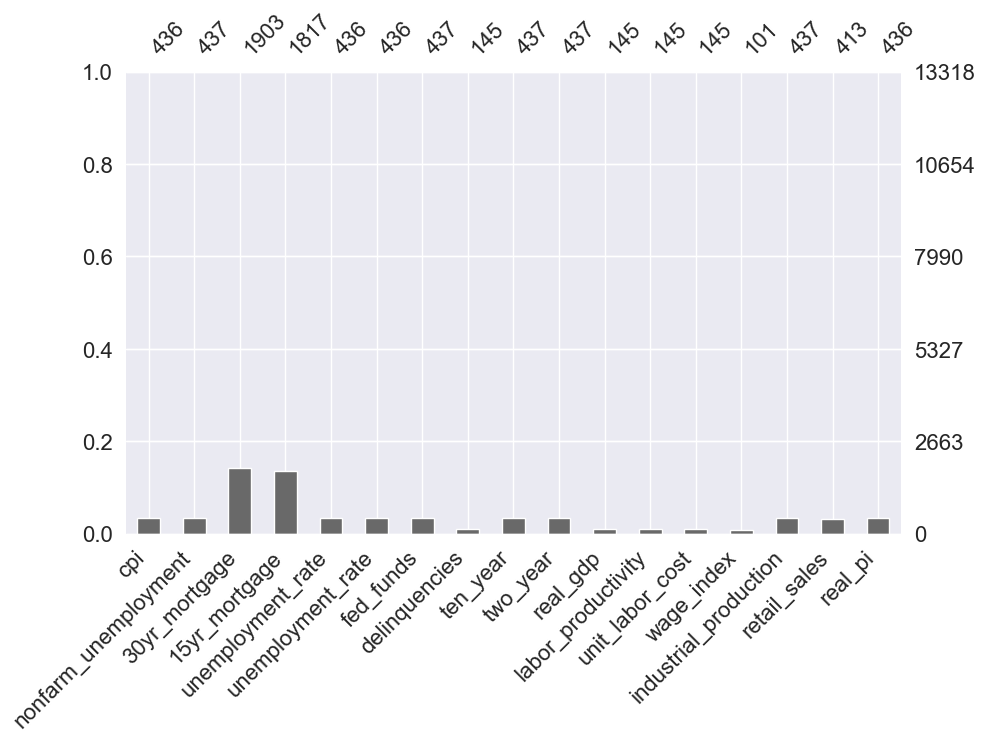

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
msno.bar(df, ax=ax)
plt.show()

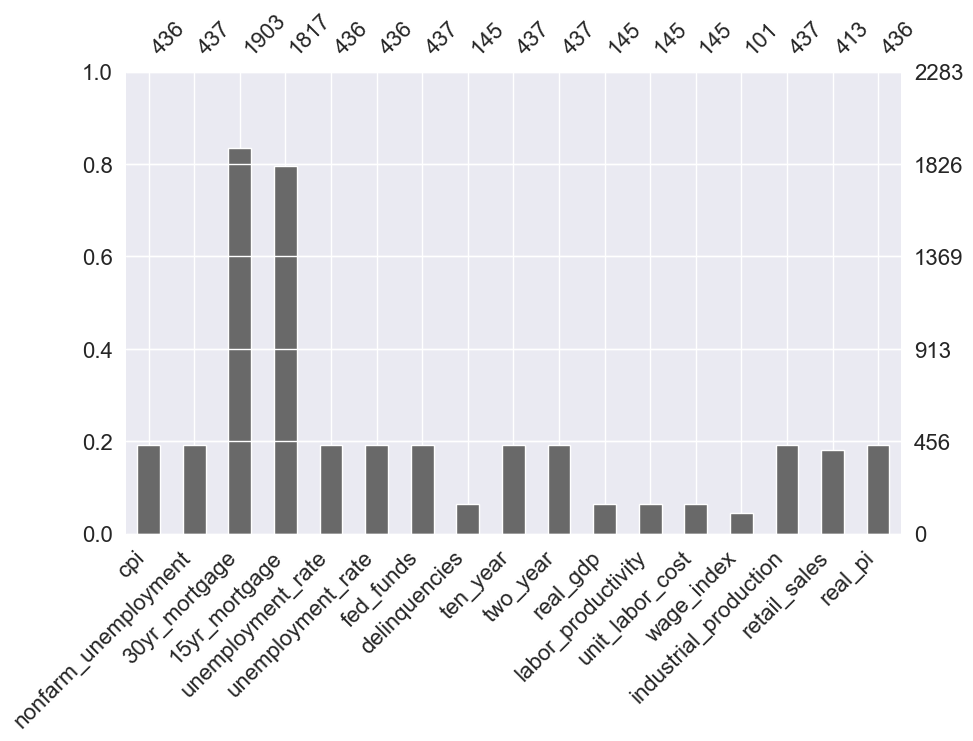

In [11]:
#import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
msno.bar(df_clean, ax=ax)
plt.show()

In [37]:
df_clean = df_clean.reset_index(names='date')

In [39]:
df_clean.head()

,date,cpi,nonfarm_unemployment,30yr_mortgage,15yr_mortgage,unemployment_rate,unemployment_rate,fed_funds,delinquencies,ten_year,two_year,real_gdp,labor_productivity,unit_labor_cost,wage_index,industrial_production,retail_sales,real_pi
0,1990-01-01,127.5,109196.0,NaN,NaN,6.0,5.4,8.23,3.6,8.21,8.09,10047.386,57.936,70.319,NaN,61.729,NaN,8170.022
1,1990-01-05,NaN,NaN,9.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-12,NaN,NaN,9.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-19,NaN,NaN,9.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-01-26,NaN,NaN,10.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,cpi,nonfarm_unemployment,30yr_mortgage,15yr_mortgage,unemployment_rate,unemployment_rate,fed_funds,delinquencies,ten_year,two_year,real_gdp,labor_productivity,unit_labor_cost,wage_index,industrial_production,retail_sales,real_pi
0,127.5,109196.0,NaN,NaN,6.0,5.4,8.23,3.6,8.21,8.09,10047.386,57.936,70.319,NaN,61.729,NaN,8170.022
1,NaN,NaN,9.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,9.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,9.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,10.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2278,NaN,NaN,6.51,5.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2279,NaN,NaN,6.53,5.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2280,NaN,NaN,6.48,5.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2281,NaN,NaN,6.52,5.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_long = pd.melt(
    df_clean, 
    id_vars='date', 
    value_vars=df_clean.iloc[:,1:].columns,
    var_name='metric', 
    value_name='rate'
)

In [56]:
df_long.head()

,date,metric,rate
0,1990-01-01,cpi,127.5
1,1990-01-05,cpi,NaN
2,1990-01-12,cpi,NaN
3,1990-01-19,cpi,NaN
4,1990-01-26,cpi,NaN


# Visualization

In [96]:
df_long.metric.unique()

array(['cpi', 'nonfarm_unemployment', '30yr_mortgage', '15yr_mortgage',
       'unemployment_rate', 'fed_funds', 'delinquencies', 'ten_year',
       'two_year', 'real_gdp', 'labor_productivity', 'unit_labor_cost',
       'wage_index', 'industrial_production', 'retail_sales', 'real_pi'],
      dtype=object)

In [98]:
t

,date,metric,rate
0,1990-01-01,cpi,127.500
4566,1990-01-01,30yr_mortgage,NaN
34245,1990-01-01,retail_sales,NaN
11415,1990-01-01,unemployment_rate,5.400
27396,1990-01-01,unit_labor_cost,70.319
...,...,...,...
22829,2026-06-18,two_year,NaN
15980,2026-06-18,fed_funds,NaN
9131,2026-06-18,15yr_mortgage,5.810
27395,2026-06-18,labor_productivity,NaN


<Axes: xlabel='date', ylabel='rate'>

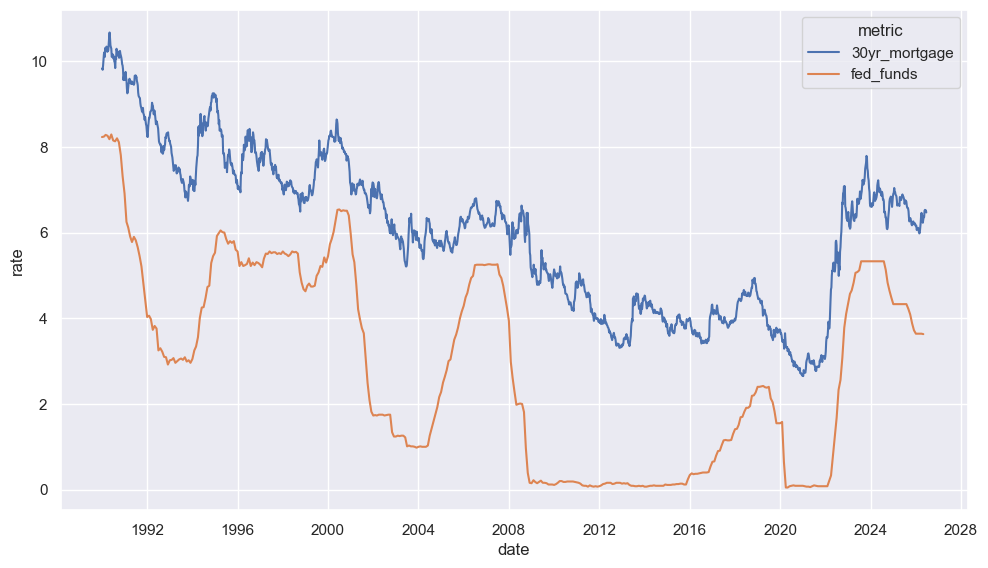

In [61]:

x = df_long.copy()
allowed_metrics = ['fed_funds','30yr_mortgage','30yr_mortgage']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='date', y='rate', hue='metric')

<Axes: xlabel='month', ylabel='rate'>

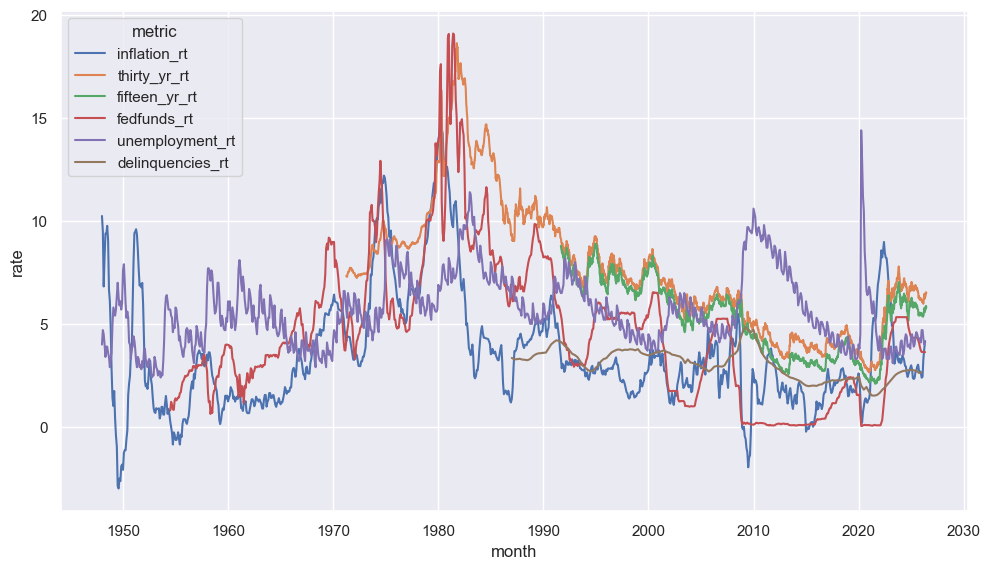

In [23]:
x = df_long.copy()
allowed_metrics = ['inflation_rt', 'thirty_yr_rt',
       'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt','fifteen_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

In [16]:
df.columns

Index(['month', 'month_str', 'inflation_rt', 'employment_nonfarm',
       'thirty_yr_rt', 'fifteen_yr_rt', 'fedfunds_rt', 'unemployment_rt',
       'delinquencies_rt', 'gdp', '10yr_treasury_rt', '2yr_treasury_rt',
       'labor_productivity', 'unit_labor_cost', 'industrial_production',
       'retail_sales', 'real_pi', 'wage_growth'],
      dtype='object')

<Axes: xlabel='month', ylabel='rate'>

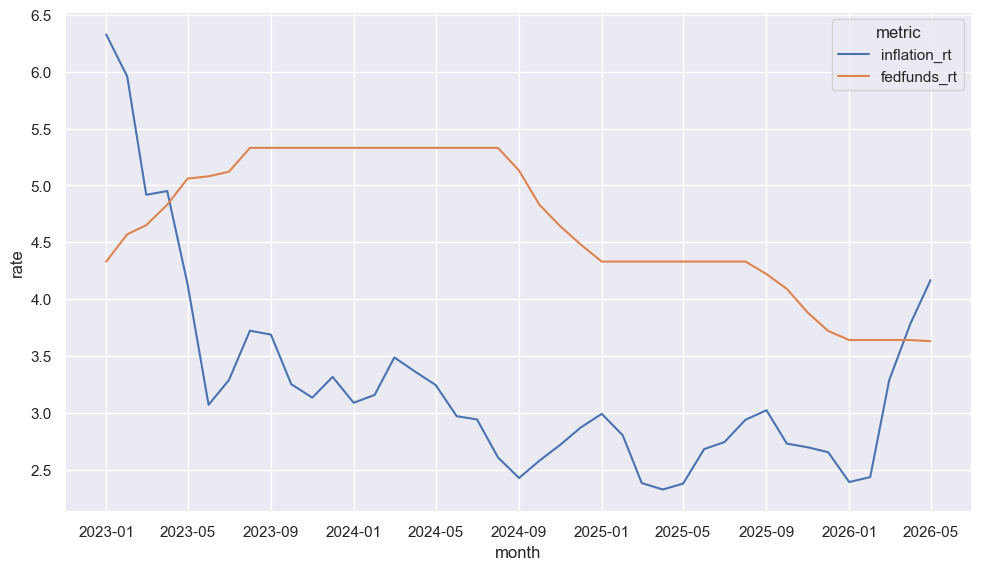

In [25]:
x = df_long.copy()
allowed_metrics = ['fedfunds_rt','inflation_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x[x['month']>='2023-01-01'], x='month', y='rate', hue='metric')

<Axes: xlabel='month', ylabel='rate'>

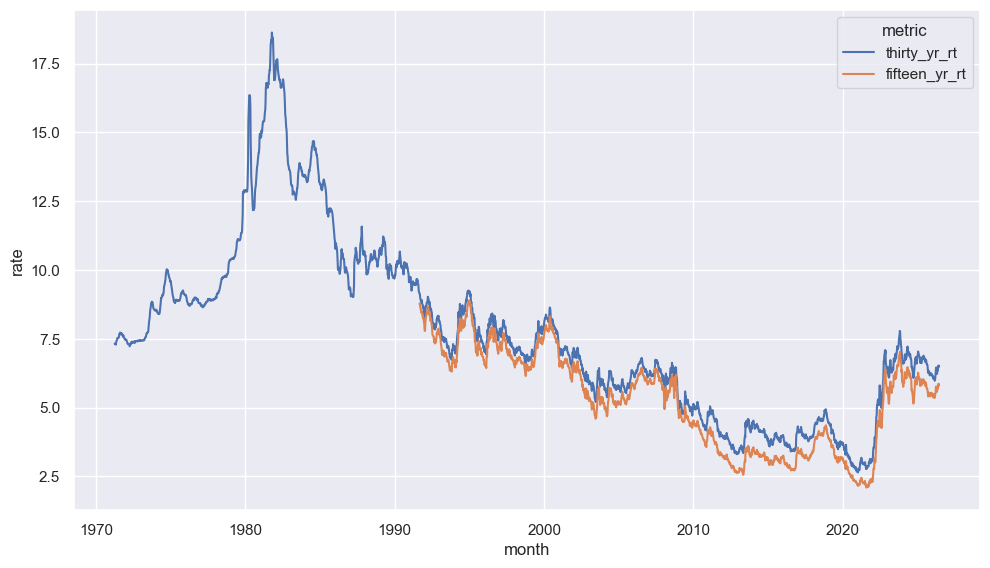

In [24]:
x = df_long.copy()
allowed_metrics = ['thirty_yr_rt','fifteen_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

<Axes: >

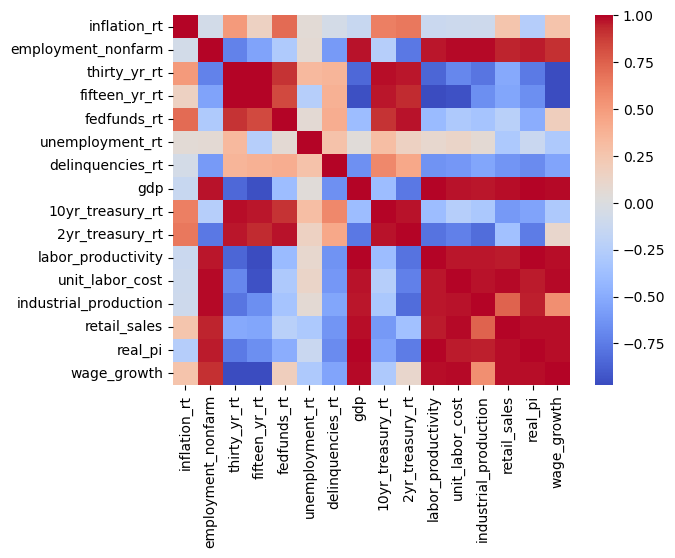

In [20]:
sns.heatmap(df.iloc[:,2:].corr(), cmap='coolwarm')

In [21]:
employed = pd.DataFrame(fred.get_series('PAYEMS')).reset_index() #mortgage rates
employed['employed_difference'] = employed[0] - employed[0].shift(1)
employed['employed_difference'] = employed['employed_difference']*1000
employed.columns = ['date','employed','employed_difference']

NameError: name 'fred' is not defined

In [ ]:
delinquencies

In [ ]:
fred.search('PAYEMS').head(5)